# PCA: retained variance, reconstruction, and subspace agreement

**Objective.** Use full SVD to reduce dimension, interpret retained variance,
and validate the result with sign-invariant comparisons to scikit-learn.

## Reproducible setup

Install the package from the repository root with `python -m pip install -e ".[dev]"`,
then select a kernel from that environment. Run all cells from top to bottom.
The algorithm is imported from `ml_from_scratch`; this notebook contains only the experiment.
All data are bundled with scikit-learn or generated locally, with seed 42.

## Mathematical intuition

Center the feature matrix: $X_c=X-\mathbf{1}\bar x^T$. If
$$X_c=U\Sigma V^T,$$
the first $k$ rows of $V^T$ are the principal directions. Scores are
$Z=X_cV_k$, reconstruction is $\hat X=ZV_k^T+\bar x$, and each explained variance
is $\sigma_j^2/(n-1)$. Retaining the largest singular values gives the best rank-$k$
centered reconstruction in squared error.

A direction and its negative describe the same subspace. Comparing signed components
directly would incorrectly flag this harmless ambiguity as a mismatch.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_digits, load_iris, load_wine
from sklearn.decomposition import PCA as ReferencePCA
from sklearn.metrics import mean_squared_error
from threadpoolctl import threadpool_limits

from ml_from_scratch import PCA

## Three datasets and independent validation

Standardize Iris and Wine features using NumPy for exploratory whole-data analysis. Scale
digits by the fixed maximum intensity, 16. Both estimators center internally, use full SVD,
report sample variance, and do not whiten. These are reconstruction diagnostics, not
held-out predictive results.

In [2]:
experiments = {}
with threadpool_limits(limits=1):
    for name, loader, dimensions in [
        ("Iris", load_iris, 2),
        ("Wine", load_wine, 5),
        ("Digits", load_digits, 20),
    ]:
        dataset = loader()
        X = (
            dataset.data / 16.0
            if name == "Digits"
            else (dataset.data - dataset.data.mean(axis=0)) / dataset.data.std(axis=0)
        )
        model = PCA(n_components=dimensions).fit(X)
        reference = ReferencePCA(n_components=dimensions, svd_solver="full").fit(X)
        reconstructed = model.inverse_transform(model.transform(X))
        reference_reconstructed = reference.inverse_transform(reference.transform(X))
        projector_gap = np.linalg.norm(
            model.components_.T @ model.components_
            - reference.components_.T @ reference.components_
        )
        experiments[name] = (X, dataset.target, model)
        print(
            f"{name:6s} k={dimensions:2d}, "
            f"variance={model.explained_variance_ratio_.sum():.6f}, "
            f"reference={reference.explained_variance_ratio_.sum():.6f}"
        )
        print(
            f"       reconstruction MSE={mean_squared_error(X, reconstructed):.8f}, "
            f"reference={mean_squared_error(X, reference_reconstructed):.8f}, "
            f"projector gap={projector_gap:.2e}"
        )

Iris   k= 2, variance=0.958132, reference=0.958132
       reconstruction MSE=0.04186793, reference=0.04186793, projector gap=8.19e-16
Wine   k= 5, variance=0.801623, reference=0.801623
       reconstruction MSE=0.19837707, reference=0.19837707, projector gap=4.45e-15
Digits k=20, variance=0.894303, reference=0.894303
       reconstruction MSE=0.00775101, reference=0.00775101, projector gap=2.70e-14


## Why compare projectors?

For orthonormal retained components $C$, the matrix $P=C^TC$ projects features onto the
retained subspace. $\|P_{ours}-P_{reference}\|_F$ ignores sign flips and rotations within
that same subspace. If equal singular values cross the component cutoff, multiple equally
valid retained subspaces can exist; reconstruction error then provides essential context.

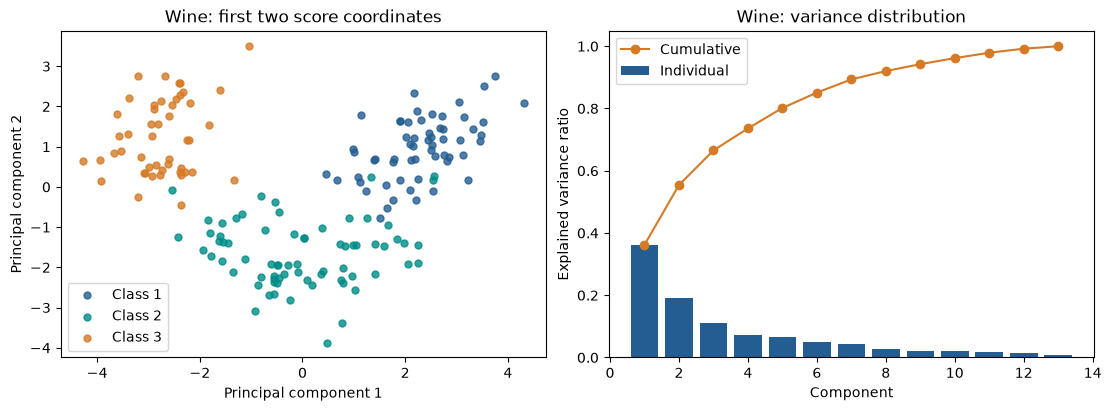

In [3]:
X_wine, wine_labels, wine_model = experiments["Wine"]
scores = wine_model.transform(X_wine)
full_wine = PCA().fit(X_wine)
figure, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
for label, color in enumerate(["#245d91", "#008c87", "#d57a25"]):
    points = scores[wine_labels == label]
    axes[0].scatter(
        points[:, 0], points[:, 1], color=color, alpha=0.8, s=25, label=f"Class {label + 1}"
    )
axes[0].set(
    xlabel="Principal component 1",
    ylabel="Principal component 2",
    title="Wine: first two score coordinates",
)
axes[0].legend()
count = np.arange(1, len(full_wine.explained_variance_ratio_) + 1)
axes[1].bar(count, full_wine.explained_variance_ratio_, color="#245d91", label="Individual")
axes[1].plot(
    count, np.cumsum(full_wine.explained_variance_ratio_), "o-", color="#d57a25", label="Cumulative"
)
axes[1].set(
    xlabel="Component",
    ylabel="Explained variance ratio",
    title="Wine: variance distribution",
    ylim=(0, 1.05),
)
axes[1].legend()
plt.show()

## Digits reconstruction

Reconstruct the first five samples from 20 coordinates instead of 64 pixel values. Plot
originals and reconstructions on the same fixed intensity scale. Only the display clips
values to that range; the reported MSE is calculated on the unmodified reconstruction.

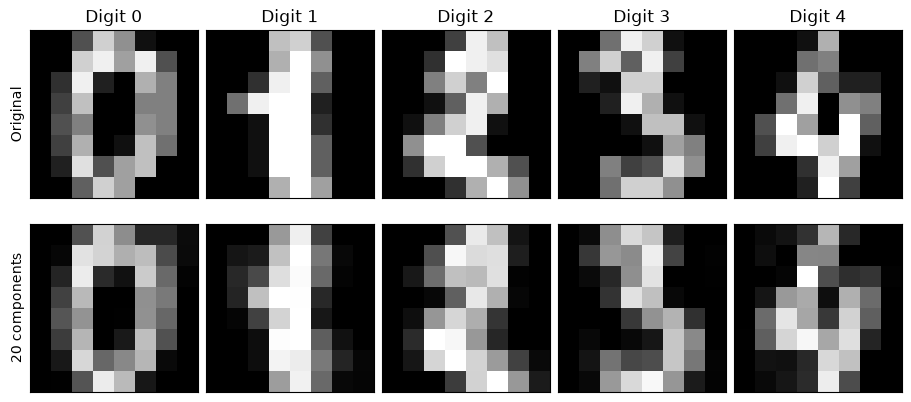

Digits variance retained: 89.43%


In [4]:
X_digits, digit_labels, digit_model = experiments["Digits"]
reconstructed_digits = digit_model.inverse_transform(digit_model.transform(X_digits[:5]))
figure, axes = plt.subplots(2, 5, figsize=(9, 4), layout="constrained")
for index in range(5):
    axes[0, index].imshow(X_digits[index].reshape(8, 8), cmap="gray", vmin=0, vmax=1)
    axes[1, index].imshow(reconstructed_digits[index].reshape(8, 8), cmap="gray", vmin=0, vmax=1)
    axes[0, index].set_title(f"Digit {digit_labels[index]}")
    for axis in axes[:, index]:
        axis.set_xticks([])
        axis.set_yticks([])
axes[0, 0].set_ylabel("Original")
axes[1, 0].set_ylabel("20 components")
plt.show()
print(f"Digits variance retained: {digit_model.explained_variance_ratio_.sum():.2%}")

## Conclusion

PCA quantifies its information tradeoff through retained variance and reconstruction
error. Subspace agreement checks the mathematical result without depending on arbitrary
component signs. Class colors make projections interpretable but never enter fitting.

Scaling is a modeling decision: standardizing heterogeneous wine features gives them
comparable influence, while digits retain their shared intensity scale. Full dense SVD
is appropriate for these datasets but does not target very large sparse matrices. The
implementation intentionally excludes whitening, randomized SVD, and incremental fitting.
See [the derivation](../docs/mathematics.md) and [benchmark methodology](../docs/benchmarking.md).